In [1]:
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import pandas as pd
data=pd.read_csv('heart.csv')
data = data.dropna() 
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [3]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
numeric_features=data.select_dtypes(include=np.number).columns
categorical_features=data.select_dtypes(exclude=np.number).columns
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')
Categorical features: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [6]:
# Display basic statistics and data profiling info
print("Data Shape:", data.shape)
print("\nData Info:")
print(data.info())
print("\nBasic Statistics:")
print(data.describe())

Data Shape: (918, 12)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Basic Statistics:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean

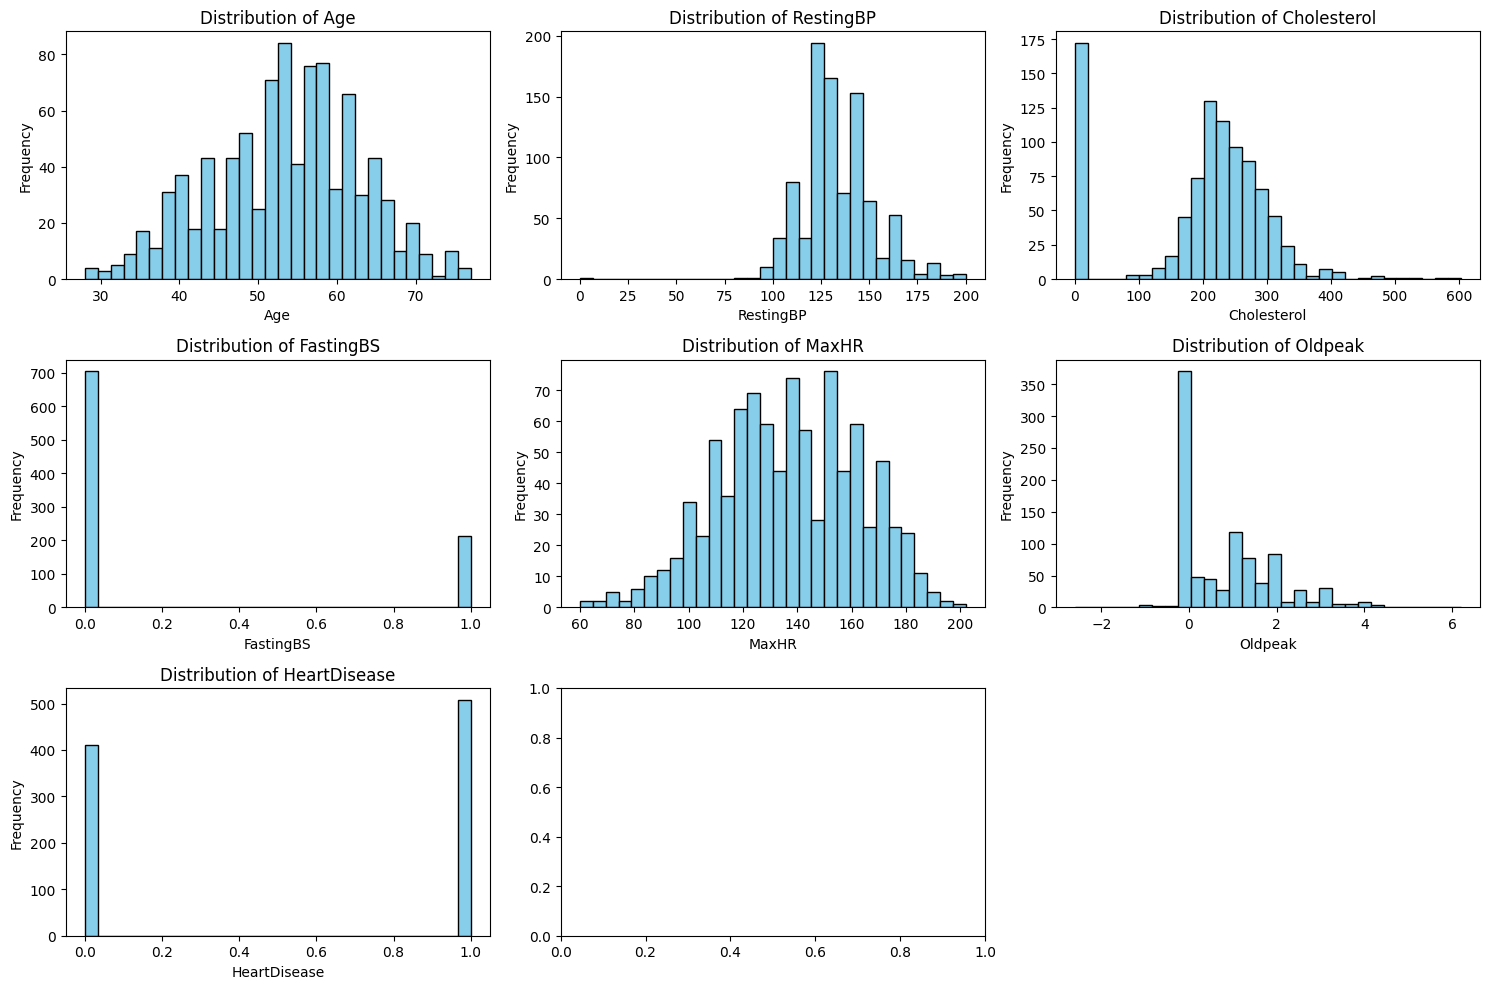

In [7]:
# Visualize distributions of numeric features
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    axes[idx].hist(data[col], bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide the last empty subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

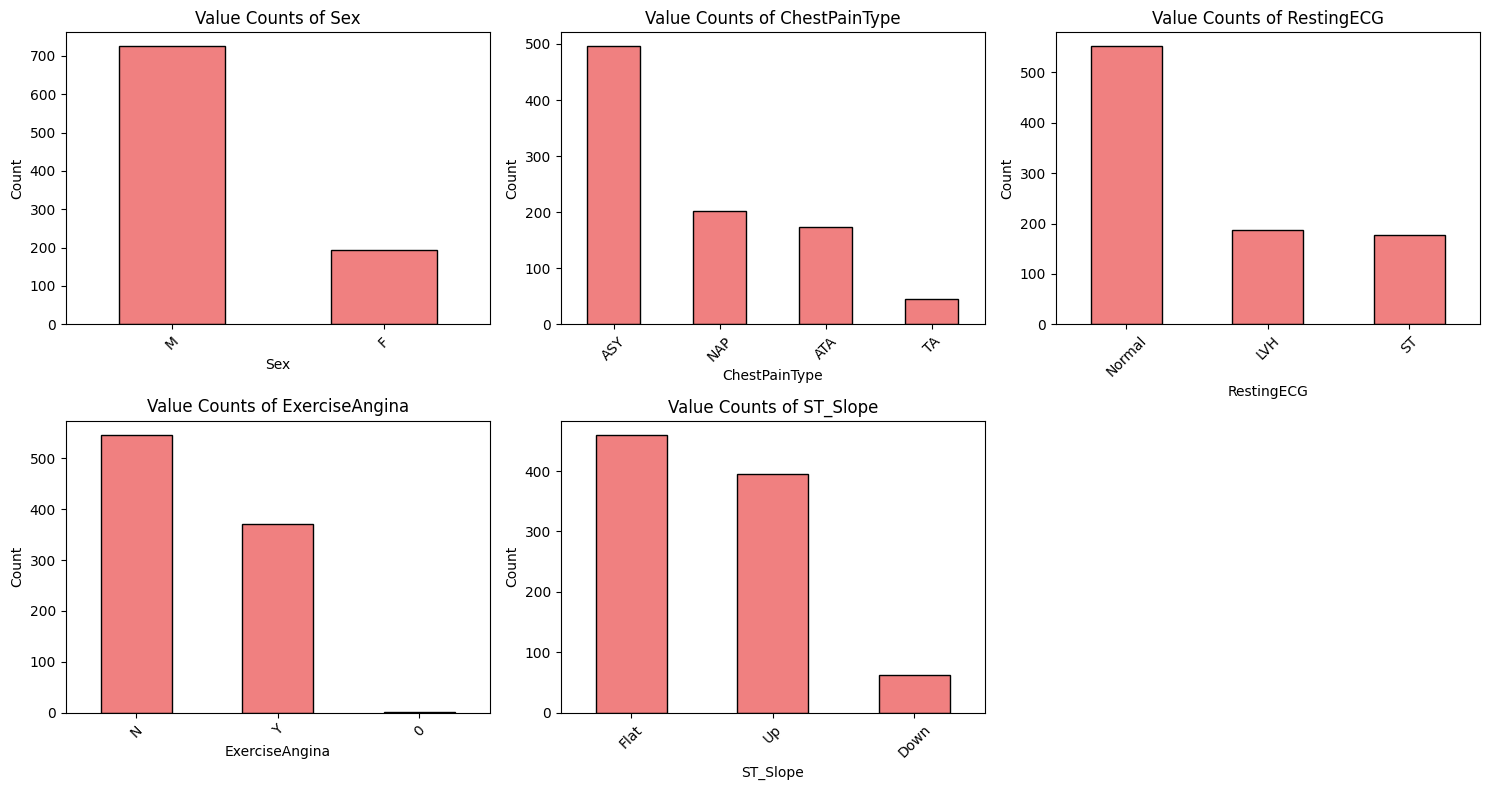

In [8]:
# Visualize categorical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    data[col].value_counts().plot(kind='bar', ax=axes[idx], color='lightcoral', edgecolor='black')
    axes[idx].set_title(f'Value Counts of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

# Hide extra subplots
for idx in range(len(categorical_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

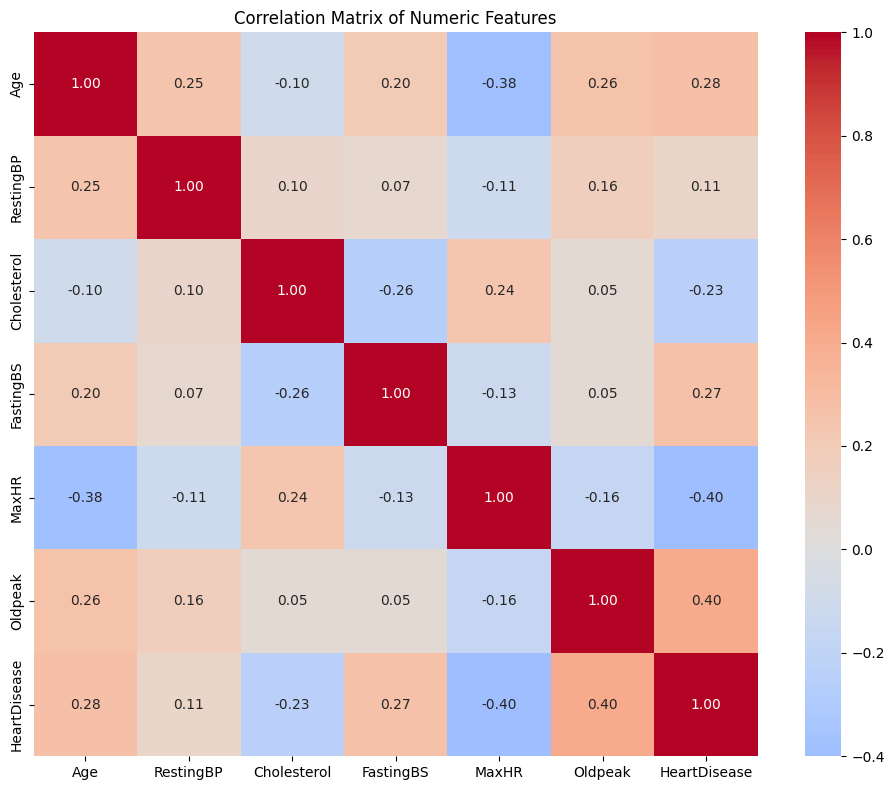

In [9]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 8))
correlation_matrix = data[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [10]:
data["Cholesterol"] = data["Cholesterol"].replace(0, data["Cholesterol"].median())
data["RestingBP"] = data["RestingBP"].replace(0, data["RestingBP"].median())
data["Oldpeak"] = data["Oldpeak"].fillna(data["Oldpeak"].median())  # Fill NaN with median

In [11]:
data['Sex'] = data['Sex'].map({'M': 1, 'F': 0})  
data[["Cholesterol","Oldpeak","RestingBP","Age","Sex","FastingBS","MaxHR","HeartDisease"]].skew()

Cholesterol     1.537360
Oldpeak         1.022872
RestingBP       0.607964
Age            -0.195933
Sex            -1.424540
FastingBS       1.264484
MaxHR          -0.144359
HeartDisease   -0.215086
dtype: float64

In [12]:
import numpy as np

data["Oldpeak"] = np.log1p(data["Oldpeak"])
data["Cholesterol"] = np.log1p(data["Cholesterol"])


d:\Projects\heaet2\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\Projects\heaet2\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
data[["Cholesterol","Oldpeak","RestingBP"]].skew()

d:\Projects\heaet2\.venv\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


Cholesterol    0.069767
Oldpeak             NaN
RestingBP      0.607964
dtype: float64

In [14]:
data[numeric_features].skew()


Age            -0.195933
RestingBP       0.607964
Cholesterol     0.069767
FastingBS       1.264484
MaxHR          -0.144359
Oldpeak              NaN
HeartDisease   -0.215086
dtype: float64

In [15]:
def check_outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(col, "Outliers count:", outliers.shape[0])

for col in ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]:
    check_outliers(col)


Age Outliers count: 0
RestingBP Outliers count: 27
Cholesterol Outliers count: 42
MaxHR Outliers count: 2
Oldpeak Outliers count: 4


In [16]:
def cap_outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data[col] = data[col].clip(lower, upper)

cap_outliers("Cholesterol")
cap_outliers("Oldpeak")
cap_outliers("RestingBP")
cap_outliers("MaxHR")


In [17]:
def check_outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(col, "Outliers count:", outliers.shape[0])

for col in ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]:
    check_outliers(col)


Age Outliers count: 0
RestingBP Outliers count: 0
Cholesterol Outliers count: 0
MaxHR Outliers count: 0
Oldpeak Outliers count: 0


In [18]:

bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)


data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,5.669881,0,Normal,172,N,0.000000,Up,0
1,49,0,NAP,160,5.198497,0,Normal,156,0,0.693147,Flat,1
2,37,1,ATA,130,5.648974,0,ST,98,N,0.000000,Up,0
3,48,0,ASY,138,5.370638,0,Normal,108,Y,0.916291,Flat,1
4,54,1,NAP,150,5.278115,0,Normal,122,N,0.000000,Up,0


In [19]:
# One-hot encode categorical columns
data = pd.get_dummies(data, columns=["ChestPainType", "RestingECG", "ST_Slope"], drop_first=True)

print("Data shape after one-hot encoding:", data.shape)
print("New columns created:", data.columns.tolist())

Data shape after one-hot encoding: (918, 16)
New columns created: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


In [20]:
from scipy.stats import chi2_contingency

# List of categorical features (the one-hot encoded columns)
categorical_cols = ['ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 
                    'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']

# Filter to only columns that exist in the data
categorical_cols = [col for col in categorical_cols if col in data.columns]

# Perform chi-square test for each categorical variable with HeartDisease
print("Chi-Square Test Results for Categorical Variables vs HeartDisease:")
print("=" * 70)

if len(categorical_cols) == 0:
    print("Note: One-hot encoded categorical columns not found in current data.")
    print("Run earlier preprocessing cells to create these columns.")
else:
    for col in categorical_cols:
        # Create contingency table
        contingency_table = pd.crosstab(data[col], data['HeartDisease'])
        
        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        print(f"\n{col}:")
        print(f"  Chi-Square Statistic: {chi2:.4f}")
        print(f"  P-value: {p_value:.6f}")
        print(f"  Degrees of Freedom: {dof}")
        
        # Interpretation
        if p_value < 0.05:
            print(f"  Result: SIGNIFICANT relationship (p < 0.05)")
        else:
            print(f"  Result: NO significant relationship (p >= 0.05)")

Chi-Square Test Results for Categorical Variables vs HeartDisease:

ChestPainType_ATA:
  Chi-Square Statistic: 146.2363
  P-value: 0.000000
  Degrees of Freedom: 1
  Result: SIGNIFICANT relationship (p < 0.05)

ChestPainType_NAP:
  Chi-Square Statistic: 40.6087
  P-value: 0.000000
  Degrees of Freedom: 1
  Result: SIGNIFICANT relationship (p < 0.05)

ChestPainType_TA:
  Chi-Square Statistic: 2.2738
  P-value: 0.131577
  Degrees of Freedom: 1
  Result: NO significant relationship (p >= 0.05)

RestingECG_Normal:
  Chi-Square Statistic: 7.3275
  P-value: 0.006791
  Degrees of Freedom: 1
  Result: SIGNIFICANT relationship (p < 0.05)

RestingECG_ST:
  Chi-Square Statistic: 9.1353
  P-value: 0.002507
  Degrees of Freedom: 1
  Result: SIGNIFICANT relationship (p < 0.05)

ST_Slope_Flat:
  Chi-Square Statistic: 279.6599
  P-value: 0.000000
  Degrees of Freedom: 1
  Result: SIGNIFICANT relationship (p < 0.05)

ST_Slope_Up:
  Chi-Square Statistic: 352.8239
  P-value: 0.000000
  Degrees of Freedom

In [21]:

# Encode ExerciseAngina BEFORE creating X, y
data['ExerciseAngina'] = data['ExerciseAngina'].map({'Y': 1, 'N': 0})

# Create X and y AFTER encoding
X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]
print("X shape:", X.shape)

X shape: (918, 15)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_fixed = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)



rf_fixed.fit(X_train_rf, y_train_rf)

print("\nMODEL 2 (Reduced Overfitting)")
print("Train Accuracy:", rf_fixed.score(X_train_rf, y_train_rf))
print("Test Accuracy:", rf_fixed.score(X_test_rf, y_test_rf))

y_pred_fixed = rf_fixed.predict(X_test_rf)
print(confusion_matrix(y_test_rf, y_pred_fixed))
print(classification_report(y_test_rf, y_pred_fixed))




MODEL 2 (Reduced Overfitting)
Train Accuracy: 0.9128065395095368
Test Accuracy: 0.842391304347826
[[64 13]
 [16 91]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.82        77
           1       0.88      0.85      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [24]:
import pickle

# Save Model 2 (Reduced Overfitting)
with open("heart_disease_model.pkl", "wb") as f:
    pickle.dump(rf_fixed, f)

print("Model saved as 'heart_disease_model.pkl'")


Model saved as 'heart_disease_model.pkl'
